# Clase: Prediccion de Precio Consumidor (2025)

Objetivo de la clase:
- limpiar y transformar datos reales
- construir un pipeline de machine learning
- comparar modelos y detectar fuga de informacion
- identificar variables utiles para predecir `precio_promedio`

## 1) Librerias

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2) Carga y funciones de limpieza

In [3]:
DATASET_NAME = 'precio_consumidor_2025.csv'
BASE_DIR = Path.cwd()

candidate_paths = [
    BASE_DIR / 'Actividad14' / DATASET_NAME,
    BASE_DIR / DATASET_NAME,
    BASE_DIR.parent / 'Actividad14' / DATASET_NAME,
    Path('Actividad14') / DATASET_NAME,
    Path(DATASET_NAME),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    tried = '\n'.join(str(p) for p in candidate_paths)
    raise FileNotFoundError(
        f'No se encontro el archivo {DATASET_NAME}. Rutas intentadas:\n{tried}'
    )

def normalize_col_name(col: str) -> str:
    col = col.replace('\"', '').replace('\ufeff', '')
    col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('ascii')
    col = col.lower().strip()
    col = re.sub(r'[^a-z0-9]+', '_', col).strip('_')
    return col

def load_and_clean(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding='latin1')
    df.columns = [normalize_col_name(c) for c in df.columns]

    for c in list(df.columns):
        if c.endswith('anio') and c != 'anio':
            df = df.rename(columns={c: 'anio'})

    df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'], errors='coerce')
    df['fecha_termino'] = pd.to_datetime(df['fecha_termino'], errors='coerce')

    df['precio_promedio'] = pd.to_numeric(
        df['precio_promedio']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    )

    if 'precio_minimo' in df.columns:
        df['precio_minimo'] = pd.to_numeric(df['precio_minimo'], errors='coerce')
    if 'precio_maximo' in df.columns:
        df['precio_maximo'] = pd.to_numeric(df['precio_maximo'], errors='coerce')

    df = df.dropna(subset=['precio_promedio', 'fecha_inicio']).copy()

    df['dia_anio'] = df['fecha_inicio'].dt.dayofyear
    df['dia_semana'] = df['fecha_inicio'].dt.dayofweek

    return df

df = load_and_clean(DATA_PATH)
print('Dataset cargado desde:', DATA_PATH)
df.head()

Dataset cargado desde: c:\xampp\htdocs\codigo\Actividad14\precio_consumidor_2025.csv


,anio,mes,semana,fecha_inicio,fecha_termino,id_region,region,sector,tipo_de_punto_monitoreo,grupo,producto,unidad,precio_minimo,precio_maximo,precio_promedio,dia_anio,dia_semana
0,2025,1,1,2024-12-30,2025-01-03,4,RegiÃ³n de Coquimbo,Coquimbo,CarnicerÃ­a,Carne bovina,Abastero,$/kilo,8998,8998,8998.000000,365,0
1,2025,1,1,2024-12-30,2025-01-03,4,RegiÃ³n de Coquimbo,Coquimbo,CarnicerÃ­a,Carne bovina,Asado Carnicero,$/kilo,8498,9898,9428.666666,365,0
2,2025,1,1,2024-12-30,2025-01-03,4,RegiÃ³n de Coquimbo,Coquimbo,CarnicerÃ­a,Carne bovina,Asado de tira,$/kilo,8998,10998,9998.000000,365,0
3,2025,1,1,2024-12-30,2025-01-03,4,RegiÃ³n de Coquimbo,Coquimbo,CarnicerÃ­a,Carne bovina,Asiento,$/kilo,10998,13998,12498.000000,365,0
4,2025,1,1,2024-12-30,2025-01-03,4,RegiÃ³n de Coquimbo,Coquimbo,CarnicerÃ­a,Carne bovina,Choclillo,$/kilo,8998,8998,8998.000000,365,0


## 3) Analisis rapido de calidad de datos

In [4]:
print('Shape:', df.shape)
print('Rango de fechas:', df['fecha_inicio'].min().date(), '->', df['fecha_inicio'].max().date())
print('Nulos por columna (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print('\nColumnas categoricas:', cat_cols)

for c in ['producto', 'region', 'sector', 'grupo', 'unidad', 'tipo_de_punto_monitoreo']:
    if c in df.columns:
        print(f'{c}:', df[c].nunique())

Shape: (333289, 17)
Rango de fechas: 2024-12-30 -> 2025-12-22
Nulos por columna (top 10):
anio                       0
mes                        0
semana                     0
fecha_inicio               0
fecha_termino              0
id_region                  0
region                     0
sector                     0
tipo_de_punto_monitoreo    0
grupo                      0
dtype: int64

Columnas categoricas: ['region', 'sector', 'tipo_de_punto_monitoreo', 'grupo', 'producto', 'unidad']
producto: 288
region: 9
sector: 41
grupo: 7
unidad: 19
tipo_de_punto_monitoreo: 7


## 4) Definir objetivo y variables

Objetivo recomendado para clase: `precio_promedio` (regresion).

Escenario A (realista): sin `precio_minimo` y `precio_maximo`.
Escenario B (comparacion didactica): incluyendo `precio_minimo` y `precio_maximo` para mostrar fuga de informacion.

In [5]:
target = 'precio_promedio'

features_without_bounds = [
    'anio', 'mes', 'semana', 'id_region', 'region', 'sector',
    'tipo_de_punto_monitoreo', 'grupo', 'producto', 'unidad',
    'dia_anio', 'dia_semana'
]

features_without_bounds = [c for c in features_without_bounds if c in df.columns]
features_with_bounds = [c for c in features_without_bounds + ['precio_minimo', 'precio_maximo'] if c in df.columns]

print('Features A:', features_without_bounds)
print('Features B:', features_with_bounds)

Features A: ['anio', 'mes', 'semana', 'id_region', 'region', 'sector', 'tipo_de_punto_monitoreo', 'grupo', 'producto', 'unidad', 'dia_anio', 'dia_semana']
Features B: ['anio', 'mes', 'semana', 'id_region', 'region', 'sector', 'tipo_de_punto_monitoreo', 'grupo', 'producto', 'unidad', 'dia_anio', 'dia_semana', 'precio_minimo', 'precio_maximo']


## 5) Split temporal (evita data leakage)

In [6]:
def split_temporal(df: pd.DataFrame, quantile: float = 0.8):
    df_sorted = df.sort_values('fecha_inicio').copy()
    cut_date = df_sorted['fecha_inicio'].quantile(quantile)
    train_df = df_sorted[df_sorted['fecha_inicio'] <= cut_date].copy()
    test_df = df_sorted[df_sorted['fecha_inicio'] > cut_date].copy()
    return train_df, test_df, cut_date

train_df, test_df, cut_date = split_temporal(df, quantile=0.8)
print('Fecha corte:', cut_date.date())
print('Train/Test:', train_df.shape, test_df.shape)

Fecha corte: 2025-10-13
Train/Test: (268894, 17) (64395, 17)


## 6) Pipeline de transformacion + modelo

In [7]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
    num_features = [c for c in X.columns if c not in cat_features]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]),
                num_features,
            ),
            (
                'cat',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]),
                cat_features,
            ),
        ]
    )
    return preprocessor

def evaluate_pipeline(pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {
        'MAE': float(mean_absolute_error(y_test, pred)),
        'RMSE': float(root_mean_squared_error(y_test, pred)),
        'R2': float(r2_score(y_test, pred)),
    }, pred

## 7) Entrenamiento y comparacion de modelos

In [8]:
results = []

y_train = train_df[target]
y_test = test_df[target]

# Escenario A: sin precio_minimo/precio_maximo
X_train_a = train_df[features_without_bounds]
X_test_a = test_df[features_without_bounds]
prep_a = build_preprocessor(X_train_a)

for name, model in {
    'dummy_mean': DummyRegressor(strategy='mean'),
    'ridge': Ridge(alpha=1.0, random_state=0),
}.items():
    pipe = Pipeline(steps=[('prep', prep_a), ('model', model)])
    metrics, _ = evaluate_pipeline(pipe, X_train_a, y_train, X_test_a, y_test)
    metrics['Escenario'] = 'A_sin_bounds'
    metrics['Modelo'] = name
    results.append(metrics)

# Escenario B: incluyendo precio_minimo/precio_maximo
if {'precio_minimo', 'precio_maximo'}.issubset(set(features_with_bounds)):
    X_train_b = train_df[features_with_bounds]
    X_test_b = test_df[features_with_bounds]
    prep_b = build_preprocessor(X_train_b)
    pipe_b = Pipeline(steps=[('prep', prep_b), ('model', Ridge(alpha=1.0, random_state=0))])
    metrics_b, pred_b = evaluate_pipeline(pipe_b, X_train_b, y_train, X_test_b, y_test)
    metrics_b['Escenario'] = 'B_con_bounds'
    metrics_b['Modelo'] = 'ridge'
    results.append(metrics_b)

pd.DataFrame(results).sort_values(['Escenario', 'MAE'])

,MAE,RMSE,R2,Escenario,Modelo
1,690.982763,1241.084742,0.936811,A_sin_bounds,ridge
0,3961.685371,4937.208739,-0.000004,A_sin_bounds,dummy_mean
2,85.908671,184.558004,0.998603,B_con_bounds,ridge


## 8) Variables mas influyentes (Ridge en escenario A)

In [9]:
pipe_ridge_a = Pipeline(steps=[
    ('prep', build_preprocessor(X_train_a)),
    ('model', Ridge(alpha=1.0, random_state=0)),
])
pipe_ridge_a.fit(X_train_a, y_train)

feature_names = pipe_ridge_a.named_steps['prep'].get_feature_names_out()
coefs = pipe_ridge_a.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs),
}).sort_values('abs_coef', ascending=False)

coef_df.head(20)

,feature,coef,abs_coef
366,cat__unidad_$/caja 180 unidades,25883.225092,25883.225092
365,cat__unidad_$/caja 100 unidades,14814.629613,14814.629613
189,cat__producto_Huevo color - Cuarta,-13997.265624,13997.265624
359,cat__unidad_$/bandeja 12 unidades,-8597.537654,8597.537654
100,cat__producto_ArÃ¡ndano (blue)|Sin especificar...,7394.468003,7394.468003
71,cat__producto_Aceite de oliva,7271.911917,7271.911917
360,cat__unidad_$/bandeja 20 unidades,-7248.346160,7248.346160
166,cat__producto_Filete,6177.368619,6177.368619
64,cat__grupo_Carne bovina,5733.621920,5733.621920
358,cat__unidad_$/Caja de 1 Litro,-5692.322318,5692.322318


## 9) Conclusiones para clase

1. Que predecir: `precio_promedio`.
2. Variables utiles: `producto`, `region`, `sector`, `tipo_de_punto_monitoreo`, `grupo`, `unidad`, y variables temporales (`mes`, `semana`, `dia_anio`, `dia_semana`).
3. Recomendacion didactica: usar escenario A para un ejercicio realista.
4. Escenario B sirve para explicar fuga de informacion y por que un R2 muy alto puede ser enganoso.

## 10) Ejercicios propuestos

1. Cambia `Ridge` por `RandomForestRegressor` y compara MAE/RMSE/R2.
2. Evalua el modelo por region (MAE por cada `region`).
3. Crea una variable de precio relativo: `precio_promedio / precio_promedio_grupo_semana`.
4. Construye una clasificacion binaria: `sube_precio` (1 si sube vs semana anterior, 0 si no).

## 11) Grafica final de resultados

Comparacion visual de metricas por escenario y modelo para cierre de clase.

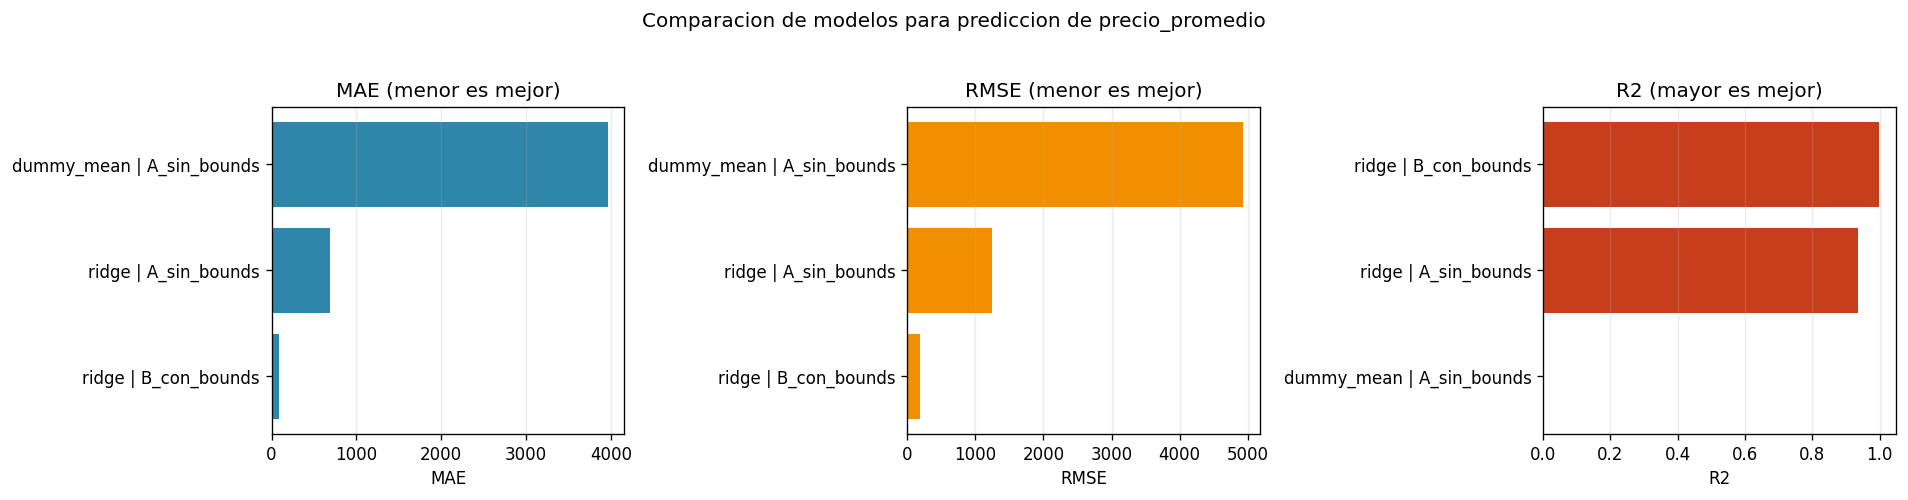

In [10]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).copy()
results_df['modelo_escenario'] = results_df['Modelo'] + ' | ' + results_df['Escenario']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)

# MAE (menor es mejor)
mae_sorted = results_df.sort_values('MAE')
axes[0].barh(mae_sorted['modelo_escenario'], mae_sorted['MAE'], color='#2E86AB')
axes[0].set_title('MAE (menor es mejor)')
axes[0].set_xlabel('MAE')

# RMSE (menor es mejor)
rmse_sorted = results_df.sort_values('RMSE')
axes[1].barh(rmse_sorted['modelo_escenario'], rmse_sorted['RMSE'], color='#F18F01')
axes[1].set_title('RMSE (menor es mejor)')
axes[1].set_xlabel('RMSE')

# R2 (mayor es mejor)
r2_sorted = results_df.sort_values('R2')
axes[2].barh(r2_sorted['modelo_escenario'], r2_sorted['R2'], color='#C73E1D')
axes[2].set_title('R2 (mayor es mejor)')
axes[2].set_xlabel('R2')

for ax in axes:
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('Comparacion de modelos para prediccion de precio_promedio', y=1.03)
plt.tight_layout()
plt.show()

## 12) Explicacion en lenguaje comun

En palabras simples, el modelo esta aprendiendo a **estimar el precio promedio** usando patrones que ve en los datos:
- que producto es,
- en que region se vende,
- en que semana del anio estamos,
- y el tipo de punto donde se monitorea.

Cuando comparamos modelos, vimos que algunos aciertan mucho mejor que otros.
- **MAE**: error promedio en pesos (mientras mas bajo, mejor).
- **RMSE**: parecido al MAE, pero castiga mas los errores grandes.
- **R2**: que tanto explica el modelo del comportamiento real (mas cerca de 1, mejor).

Una duda muy comun es esta:
- Si `cat__producto_Lomo Liso` tiene un promedio cercano a `15224`, por que el coeficiente del modelo Ridge en el escenario A aparece cerca de `4046.56`?

La respuesta en lenguaje comun es:
- **15224** es el precio promedio observado de Lomo Liso mirado "solo" como producto.
- **4046.56** no es el precio de Lomo Liso. Es solo el **aporte adicional** que el modelo le asigna a ese producto respecto de una base general.
- El modelo no decide mirando solo el producto; tambien mira region, sector, semana, unidad y otras variables al mismo tiempo.
- Por eso, el precio final predicho se arma como una suma: una base general + efecto del producto + efecto de la region + efecto del tiempo + otros ajustes.
- Ademas, como es un modelo **Ridge**, los coeficientes se encogen un poco hacia cero para evitar sobreajuste. Eso hace que no coincidan con un promedio simple.

En otras palabras:
- El promedio de `Lomo Liso` responde a la pregunta: **"cuanto vale normalmente este producto en el dataset?"**
- El coeficiente de Ridge responde a otra pregunta: **"cuanto sube o baja la prediccion cuando el producto es Lomo Liso, manteniendo el resto de las variables en juego?"**

Ejemplo intuitivo:
- imagina que el modelo parte desde una idea general del precio, por ejemplo un valor base.
- luego suma o resta segun el producto, la region y la semana.
- entonces `4046.56` seria una parte de esa construccion, no el precio completo.

Lo importante para clase es esto:
1. Si usamos variables realistas (sin pistas directas del precio), el ejercicio se parece a un caso real de negocio.
2. Si agregamos variables demasiado cercanas al resultado final, el modelo parece "perfecto", pero puede ser una **falsa sensacion de exito** (fuga de informacion).
3. En ciencia de datos no solo importa un R2 alto: tambien importa que el modelo sea justo, explicable y util en produccion.

Conclusion practica:
- Este dataset sirve muy bien para enseniar **limpieza, transformacion, feature engineering y modelado**.
- El objetivo recomendado para estudiantes es predecir `precio_promedio` con variables disponibles antes de conocer el precio final.